In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import warnings
import json
import calendar
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants
import astropy.time
import astropy.coordinates
import astropy.visualization
import named_arrays as na
import ussa1976
import pymsis

In [3]:
astropy.visualization.quantity_support();

In [4]:
year = 2027
date_launch_min = f"{year}-02-06"
date_launch_max = f"{year}-06-21"

axis_site = "site"
axis_time = "time"
axis_height = "height"
axis_distance = "distance"
axis_wavelength = "wavelength"
axis_z = "z_model"
axis_f107 = "f107"

sites = {
    "Poker Flat Research Range": astropy.coordinates.EarthLocation(
        lat=65.1192 * u.deg,
        lon=-147.4322 * u.deg,
        height=213 * u.m,
    ),
    "White Sands Missile Range": astropy.coordinates.EarthLocation(
        lat=32.4177 * u.deg,
        lon=-106.3717 * u.deg,
        height=1225 * u.m,
    ),
}

t0 = astropy.time.Time(f"{year}-01-01", scale="utc")
num_days = 365


def index_date(d: str) -> int:
    """The index along the time axis corresponding to the given date."""
    return int(round((astropy.time.Time(d) - t0).jd))

In [5]:
day = np.arange(num_days)
step = 10 * u.min
hour = np.arange(0, 24, step.to_value(u.hr))

times = t0 + day[:, np.newaxis] * u.day + hour[np.newaxis, :] * u.hr

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sun = astropy.coordinates.get_sun(times)
    alt_noon = []
    time_noon = []
    for site in sites:
        frame = astropy.coordinates.AltAz(obstime=times, location=sites[site])
        alt = sun.transform_to(frame).alt.deg
        index = np.argmax(alt, axis=1)
        alt_noon.append(np.take_along_axis(alt, index[:, np.newaxis], axis=1)[:, 0])
        time_noon.append(times[np.arange(num_days), index].datetime64)

alt_noon = na.ScalarArray(np.stack(alt_noon) << u.deg, axes=(axis_site, axis_time))
time_noon = na.ScalarArray(np.stack(time_noon), axes=(axis_site, axis_time))
date = na.ScalarArray((t0 + day * u.day).datetime64, axes=(axis_time,))

In [6]:
hour_noon = na.ScalarArray(
    ndarray=(time_noon.ndarray - time_noon.ndarray.astype("datetime64[D]")) / np.timedelta64(1, "h") * u.hr,
    axes=time_noon.axes,
)

for i, site in enumerate(sites):
    hour = hour_noon[{axis_site: i}]
    print(f"{site}: local noon from {hour.min().ndarray:.2f} to {hour.max().ndarray:.2f} UTC")

Poker Flat Research Range: local noon from 21.50 h to 22.00 h UTC
White Sands Missile Range: local noon from 18.83 h to 19.33 h UTC


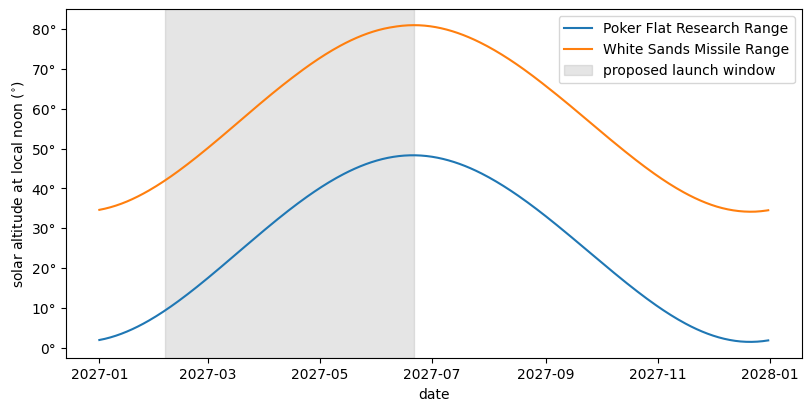

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for i, site in enumerate(sites):
    na.plt.plot(date, alt_noon[{axis_site: i}], ax=ax, axis=axis_time, label=site)
ax.axvspan(
    np.datetime64(date_launch_min),
    np.datetime64(date_launch_max),
    color="gray",
    alpha=0.2,
    label="proposed launch window",
)
ax.set_xlabel("date")
ax.set_ylabel(f"solar altitude at local noon ({u.deg:latex_inline})")
ax.legend();

In [8]:
with open("predicted-solar-cycle.json") as file:
    solar_cycle = json.load(file)

solar_cycle = sorted(
    (r for r in solar_cycle if r["time-tag"].startswith(str(year))),
    key=lambda r: r["time-tag"],
)

month_f107 = np.array([np.datetime64(r["time-tag"]) for r in solar_cycle])
f107_predicted = np.array([r["predicted_f10.7"] for r in solar_cycle])
f107_low = np.array([r["low_f10.7"] for r in solar_cycle])
f107_high = np.array([r["high_f10.7"] for r in solar_cycle])

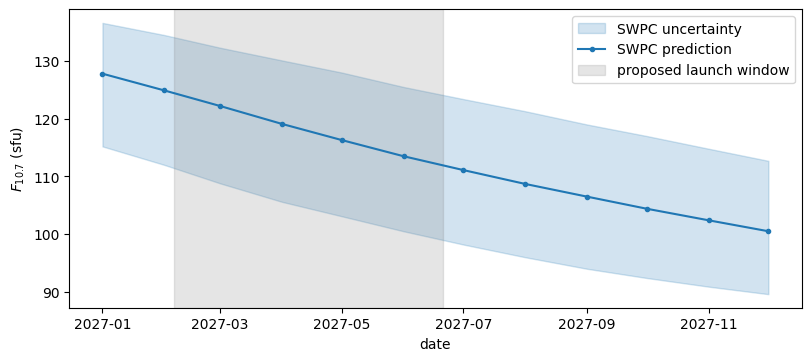

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
ax.fill_between(
    month_f107,
    f107_low,
    f107_high,
    color="tab:blue",
    alpha=0.2,
    label="SWPC uncertainty",
)
ax.plot(
    month_f107,
    f107_predicted,
    color="tab:blue",
    marker="o",
    markersize=3,
    label="SWPC prediction",
)
ax.axvspan(
    np.datetime64(date_launch_min),
    np.datetime64(date_launch_max),
    color="gray",
    alpha=0.2,
    label="proposed launch window",
)
ax.set_xlabel("date")
ax.set_ylabel("$F_{10.7}$ (sfu)")
ax.legend();

In [10]:
month = (t0 + day * u.day).ymdhms.month
f107 = f107_predicted[month - 1]
ap = 4.0

In [11]:
num_z = 501
z_model = na.linspace(0, 1000, axis=axis_z, num=num_z) * u.km
dz_model = z_model[{axis_z: 1}] - z_model[{axis_z: 0}]

n_o2 = []
for i, site in enumerate(sites):
    result = pymsis.calculate(
        dates=time_noon[{axis_site: i}].ndarray,
        lons=sites[site].lon.to_value(u.deg),
        lats=sites[site].lat.to_value(u.deg),
        alts=z_model.ndarray.to_value(u.km),
        f107s=f107,
        f107as=f107,
        aps=np.broadcast_to(ap, (num_days, 7)),
        version=2.1,
    )
    n_o2.append(result[:, 0, 0, :, pymsis.Variable.O2])

n_o2 = na.ScalarArray(np.stack(n_o2) << u.m**-3, axes=(axis_site, axis_time, axis_z))
log_n_o2 = np.log(n_o2.to_value(u.m**-3))
index_model = na.indices(log_n_o2.shape)

In [12]:
def number_density_o2(h: na.AbstractScalar) -> na.AbstractScalar:
    """
    The number density of molecular oxygen at a height `h` above sea level,
    interpolated log-linearly from the NRLMSIS grid for each launch site and
    date.
    Heights outside the grid are clamped to the nearest endpoint.
    """
    index = ((h - z_model[{axis_z: 0}]) / dz_model).to_value(u.dimensionless_unscaled)
    index = np.clip(index, 0, num_z - 2)
    index_0 = index.astype(int)
    weight = index - index_0

    def gather(offset: int) -> na.AbstractScalar:
        return log_n_o2[{
            axis_site: index_model[axis_site],
            axis_time: index_model[axis_time],
            axis_z: index_0 + offset,
        }]

    return np.exp((1 - weight) * gather(0) + weight * gather(1)) << u.m**-3

In [13]:
atmosphere_ussa = ussa1976.compute(
    z=z_model.ndarray.to_value(u.m),
    variables=["n"],
)
n_o2_ussa = na.ScalarArray(
    ndarray=atmosphere_ussa["n"].sel(s="O2").values << u.m**-3,
    axes=(axis_z,),
)

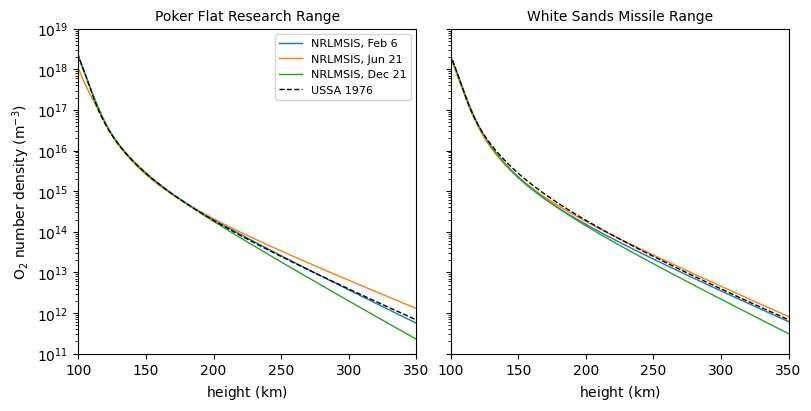

In [14]:
fig, axs = plt.subplots(
    ncols=2,
    sharey=True,
    figsize=(8, 4),
    constrained_layout=True,
)
for i, site in enumerate(sites):
    ax = axs[i]
    for label, d in [("Feb 6", date_launch_min), ("Jun 21", date_launch_max), ("Dec 21", f"{year}-12-21")]:
        na.plt.plot(
            z_model,
            n_o2[{axis_site: i, axis_time: index_date(d)}],
            ax=ax,
            axis=axis_z,
            label=f"NRLMSIS, {label}",
            linewidth=1,
        )
    na.plt.plot(
        z_model,
        n_o2_ussa,
        ax=ax,
        axis=axis_z,
        color="black",
        linestyle="--",
        linewidth=1,
        label="USSA 1976",
    )
    ax.set_yscale("log")
    ax.set_xlim(100, 350)
    ax.set_ylim(1e11, 1e19)
    ax.set_title(site, fontsize=10)
    ax.set_xlabel(f"height ({u.km:latex_inline})")
axs[0].set_ylabel(f"O$_2$ number density ({u.m**-3:latex_inline})")
axs[0].legend(fontsize=8);

In [15]:
height = na.linspace(150, 300, axis=axis_height, num=16) * u.km

zenith = 90 * u.deg - alt_noon

distance_max = 3000 * u.km
num_distance = 600
distance = na.linspace(0, 1, axis=axis_distance, num=num_distance, centers=True) * distance_max
d_distance = distance_max / num_distance

r0 = astropy.constants.R_earth + height
r = np.sqrt(np.square(r0) + np.square(distance) + 2 * r0 * distance * np.cos(zenith))
h_path = r - astropy.constants.R_earth

column_o2 = (number_density_o2(h_path) * d_distance).sum(axis_distance)
column_o2 = column_o2.to(u.cm**-2)

In [16]:
data_cross_section = np.loadtxt("O2_Lu2010_303.7K_115-180nm.txt")

where_furst = data_cross_section[:, 0] >= 120

wavelength = na.ScalarArray(
    ndarray=data_cross_section[where_furst, 0] * u.nm,
    axes=(axis_wavelength,),
)
cross_section_o2 = na.ScalarArray(
    ndarray=data_cross_section[where_furst, 1] * u.cm**2,
    axes=(axis_wavelength,),
)

wavelength_lya = 121.567 * u.nm
cross_section_lya = 1.0e-20 * u.cm**2

lines_furst = {
    "H I": 121.6 * u.nm,
    "O I": 130.4 * u.nm,
    "C II": 133.5 * u.nm,
    "Si IV": 139.4 * u.nm,
    "C IV": 154.9 * u.nm,
    "C I": 165.7 * u.nm,
}

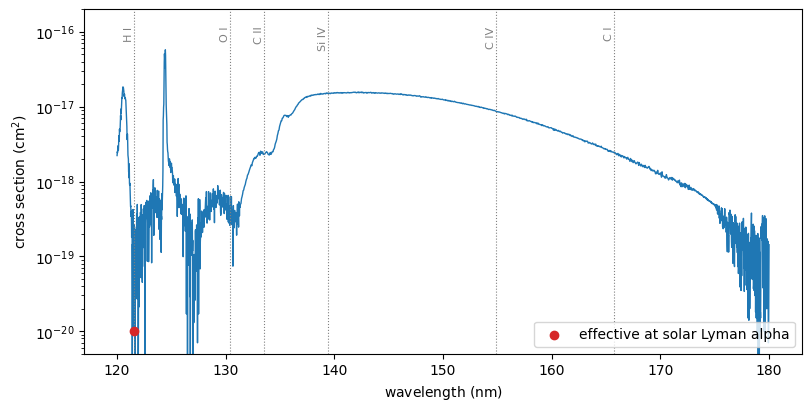

In [17]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
na.plt.plot(wavelength, cross_section_o2, ax=ax, axis=axis_wavelength, linewidth=1)
ax.scatter(
    wavelength_lya,
    cross_section_lya,
    color="tab:red",
    zorder=3,
    label="effective at solar Lyman alpha",
)
for line in lines_furst:
    ax.axvline(lines_furst[line], color="gray", linestyle=":", linewidth=0.8)
    ax.text(
        x=lines_furst[line].to_value(u.nm),
        y=1.2e-16,
        s=line,
        rotation=90,
        ha="right",
        va="top",
        fontsize=8,
        color="gray",
    )
ax.set_yscale("log")
ax.set_ylim(5e-21, 2e-16)
ax.set_xlabel(f"wavelength ({u.nm:latex_inline})")
ax.set_ylabel(f"cross section ({u.cm**2:latex_inline})")
ax.legend(loc="lower right");

In [18]:
where_continuum = wavelength > 131 * u.nm

index_worst = np.argmax(cross_section_o2 * where_continuum, axis=axis_wavelength)
wavelength_worst = wavelength[index_worst]
cross_section_worst = cross_section_o2[index_worst]

transmission_worst = np.exp(-cross_section_worst * column_o2)

dates_season = {
    "window opens (Feb 6)": date_launch_min,
    "window closes (Jun 21)": date_launch_max,
    "winter solstice": f"{year}-12-21",
}

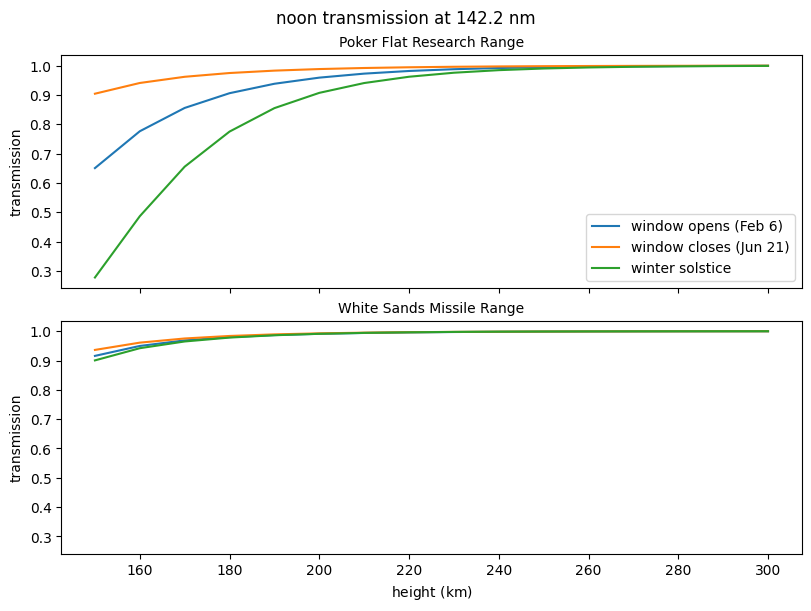

In [19]:
fig, axs = plt.subplots(
    nrows=len(sites),
    sharex=True,
    sharey=True,
    figsize=(8, 6),
    constrained_layout=True,
)
for i, site in enumerate(sites):
    ax = axs[i]
    for season in dates_season:
        na.plt.plot(
            height,
            transmission_worst[{axis_site: i, axis_time: index_date(dates_season[season])}],
            ax=ax,
            axis=axis_height,
            label=season,
        )
    ax.set_title(site, fontsize=10)
    ax.set_ylabel("transmission")
axs[~0].set_xlabel(f"height ({u.km:latex_inline})")
axs[0].legend()
fig.suptitle(f"noon transmission at {wavelength_worst.ndarray:.1f}");

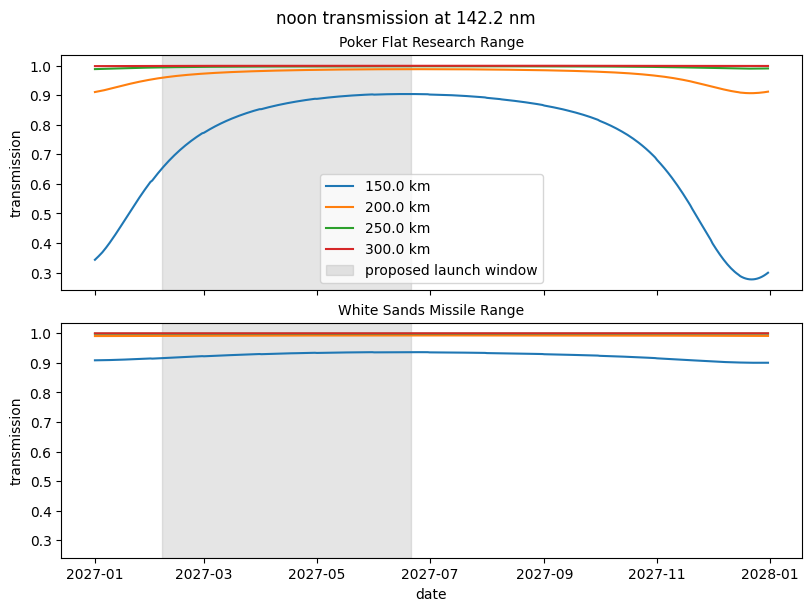

In [20]:
heights_plot = [150, 200, 250, 300] * u.km

fig, axs = plt.subplots(
    nrows=len(sites),
    sharex=True,
    sharey=True,
    figsize=(8, 6),
    constrained_layout=True,
)
for i, site in enumerate(sites):
    ax = axs[i]
    for h in heights_plot:
        index_h = np.argmin(np.abs(height - h), axis=axis_height)
        na.plt.plot(
            date,
            transmission_worst[index_h][{axis_site: i}],
            ax=ax,
            axis=axis_time,
            label=f"{h}",
        )
    ax.axvspan(
        np.datetime64(date_launch_min),
        np.datetime64(date_launch_max),
        color="gray",
        alpha=0.2,
        label="proposed launch window",
    )
    ax.set_title(site, fontsize=10)
    ax.set_ylabel("transmission")
axs[~0].set_xlabel("date")
axs[0].legend()
fig.suptitle(f"noon transmission at {wavelength_worst.ndarray:.1f}");

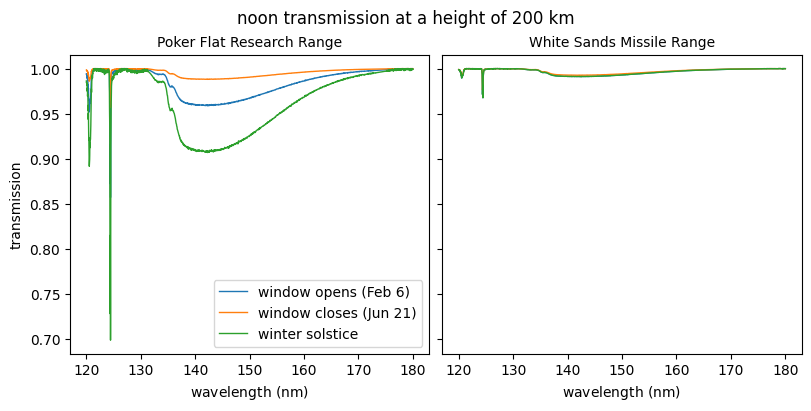

In [21]:
index_200 = np.argmin(np.abs(height - 200 * u.km), axis=axis_height)
transmission_200 = np.exp(-cross_section_o2 * column_o2[index_200])

fig, axs = plt.subplots(
    ncols=len(sites),
    sharex=True,
    sharey=True,
    figsize=(8, 4),
    constrained_layout=True,
)
for i, site in enumerate(sites):
    ax = axs[i]
    for season in dates_season:
        na.plt.plot(
            wavelength,
            transmission_200[{axis_site: i, axis_time: index_date(dates_season[season])}],
            ax=ax,
            axis=axis_wavelength,
            label=season,
            linewidth=1,
        )
    ax.set_title(site, fontsize=10)
    ax.set_xlabel(f"wavelength ({u.nm:latex_inline})")
axs[0].set_ylabel("transmission")
axs[0].legend()
fig.suptitle("noon transmission at a height of 200 km");

In [22]:
column_vertical = (number_density_o2(height + distance) * d_distance).sum(axis_distance)
column_flat = (column_vertical / np.cos(zenith)).to(u.cm**-2)

transmission_flat_worst = np.exp(-cross_section_worst * column_flat)

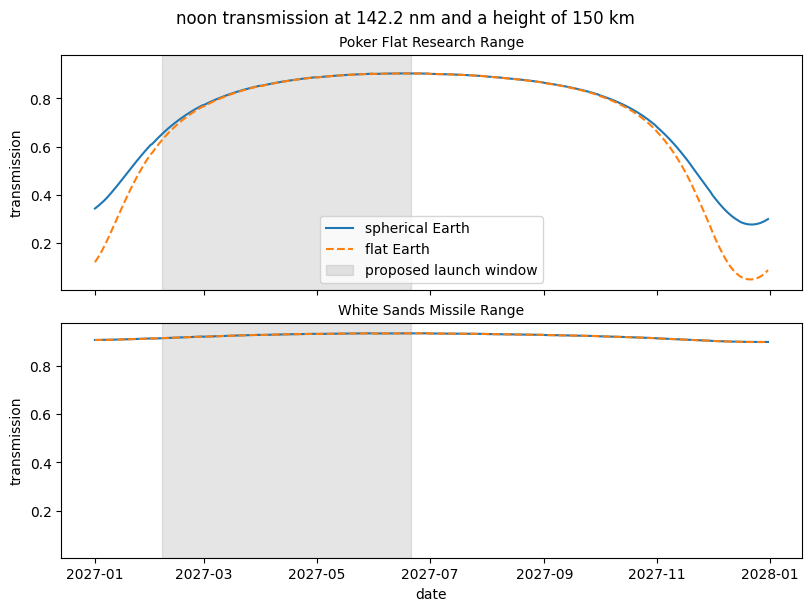

In [23]:
index_150 = np.argmin(np.abs(height - 150 * u.km), axis=axis_height)

fig, axs = plt.subplots(
    nrows=len(sites),
    sharex=True,
    sharey=True,
    figsize=(8, 6),
    constrained_layout=True,
)
for i, site in enumerate(sites):
    ax = axs[i]
    na.plt.plot(
        date,
        transmission_worst[index_150][{axis_site: i}],
        ax=ax,
        axis=axis_time,
        label="spherical Earth",
    )
    na.plt.plot(
        date,
        transmission_flat_worst[index_150][{axis_site: i}],
        ax=ax,
        axis=axis_time,
        linestyle="--",
        label="flat Earth",
    )
    ax.axvspan(
        np.datetime64(date_launch_min),
        np.datetime64(date_launch_max),
        color="gray",
        alpha=0.2,
        label="proposed launch window",
    )
    ax.set_title(site, fontsize=10)
    ax.set_ylabel("transmission")
axs[~0].set_xlabel("date")
axs[0].legend()
fig.suptitle(f"noon transmission at {wavelength_worst.ndarray:.1f} and a height of 150 km");

In [24]:
for i, site in enumerate(sites):
    print(site)
    for season in ("window opens (Feb 6)", "winter solstice"):
        index = {axis_site: i, axis_time: index_date(dates_season[season])}
        for h in ([150, 200] * u.km):
            index_h = np.argmin(np.abs(height - h), axis=axis_height)
            t_sph = transmission_worst[index_h][index]
            t_flat = transmission_flat_worst[index_h][index]
            print(
                f"  {season}, {h}:"
                f" T(spherical) = {t_sph.ndarray:.3f},"
                f" T(flat) = {t_flat.ndarray:.3f}"
            )

Poker Flat Research Range
  window opens (Feb 6), 150.0 km: T(spherical) = 0.650, T(flat) = 0.625
  window opens (Feb 6), 200.0 km: T(spherical) = 0.959, T(flat) = 0.954
  winter solstice, 150.0 km: T(spherical) = 0.277, T(flat) = 0.049
  winter solstice, 200.0 km: T(spherical) = 0.907, T(flat) = 0.783
White Sands Missile Range
  window opens (Feb 6), 150.0 km: T(spherical) = 0.916, T(flat) = 0.916
  window opens (Feb 6), 200.0 km: T(spherical) = 0.991, T(flat) = 0.991
  winter solstice, 150.0 km: T(spherical) = 0.900, T(flat) = 0.900
  winter solstice, 200.0 km: T(spherical) = 0.991, T(flat) = 0.991


In [25]:
index_window = {axis_time: slice(index_date(date_launch_min), index_date(date_launch_max) + 1)}

for i, site in enumerate(sites):
    print(site)
    alt_window = alt_noon[index_window][{axis_site: i}]
    print(f"  noon solar altitude: {alt_window.min().ndarray:.1f} to {alt_window.max().ndarray:.1f}")
    for h in ([150, 200, 250, 300] * u.km):
        index_h = np.argmin(np.abs(height - h), axis=axis_height)
        t_worst = transmission_worst[index_h][index_window][{axis_site: i}]
        t_lya = np.exp(-cross_section_lya * column_o2[index_h][index_window][{axis_site: i}])
        print(
            f"  {h}:"
            f" T({wavelength_worst.ndarray:.1f}) = {t_worst.min().ndarray:.3f} to {t_worst.max().ndarray:.3f},"
            f" T(Lyman alpha) >= {t_lya.min().ndarray:.3f}"
        )

Poker Flat Research Range
  noon solar altitude: 9.4 deg to 48.3 deg
  150.0 km: T(142.2 nm) = 0.650 to 0.904, T(Lyman alpha) >= 1.000
  200.0 km: T(142.2 nm) = 0.959 to 0.988, T(Lyman alpha) >= 1.000
  250.0 km: T(142.2 nm) = 0.994 to 0.998, T(Lyman alpha) >= 1.000
  300.0 km: T(142.2 nm) = 0.999 to 1.000, T(Lyman alpha) >= 1.000
White Sands Missile Range
  noon solar altitude: 42.1 deg to 81.0 deg
  150.0 km: T(142.2 nm) = 0.916 to 0.936, T(Lyman alpha) >= 1.000
  200.0 km: T(142.2 nm) = 0.991 to 0.993, T(Lyman alpha) >= 1.000
  250.0 km: T(142.2 nm) = 0.999 to 0.999, T(Lyman alpha) >= 1.000
  300.0 km: T(142.2 nm) = 1.000 to 1.000, T(Lyman alpha) >= 1.000


In [26]:
index_open = index_date(date_launch_min)
index_month_open = astropy.time.Time(date_launch_min).ymdhms.month - 1

f107_grid = np.arange(70.0, 205.0, 5.0)
f107_sensitivity = na.ScalarArray(f107_grid, axes=(axis_f107,))

profile_f107 = []
for i, site in enumerate(sites):
    result = pymsis.calculate(
        dates=np.broadcast_to(
            time_noon[{axis_site: i, axis_time: index_open}].ndarray,
            f107_grid.shape,
        ),
        lons=sites[site].lon.to_value(u.deg),
        lats=sites[site].lat.to_value(u.deg),
        alts=z_model.ndarray.to_value(u.km),
        f107s=f107_grid,
        f107as=f107_grid,
        aps=np.broadcast_to(ap, f107_grid.shape + (7,)),
        version=2.1,
    )
    profile_f107.append(result[:, 0, 0, :, pymsis.Variable.O2])

log_n_o2_f107 = np.log(np.stack(profile_f107))
log_n_o2_f107 = na.ScalarArray(log_n_o2_f107, axes=(axis_site, axis_f107, axis_z))
index_f107 = na.indices(log_n_o2_f107.shape)

In [27]:
h_open = h_path[{axis_time: index_open}]

index = ((h_open - z_model[{axis_z: 0}]) / dz_model).to_value(u.dimensionless_unscaled)
index = np.clip(index, 0, num_z - 2)
index_0 = index.astype(int)
weight = index - index_0


def gather_f107(offset: int) -> na.AbstractScalar:
    return log_n_o2_f107[{
        axis_site: index_f107[axis_site],
        axis_f107: index_f107[axis_f107],
        axis_z: index_0 + offset,
    }]


n_o2_open = np.exp((1 - weight) * gather_f107(0) + weight * gather_f107(1)) << u.m**-3

column_f107 = (n_o2_open * d_distance).sum(axis_distance).to(u.cm**-2)
transmission_f107 = np.exp(-cross_section_worst * column_f107)

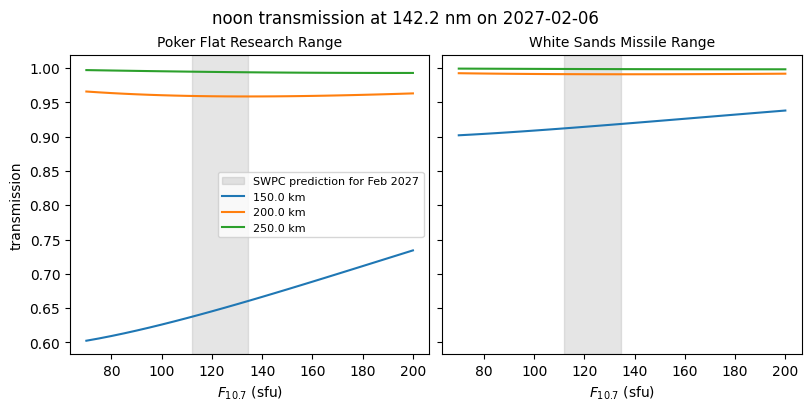

In [28]:
fig, axs = plt.subplots(
    ncols=len(sites),
    sharex=True,
    sharey=True,
    figsize=(8, 4),
    constrained_layout=True,
)
for i, site in enumerate(sites):
    ax = axs[i]
    ax.axvspan(
        f107_low[index_month_open],
        f107_high[index_month_open],
        color="gray",
        alpha=0.2,
        label=f"SWPC prediction for {calendar.month_abbr[index_month_open + 1]} {year}",
    )
    for h in ([150, 200, 250] * u.km):
        index_h = np.argmin(np.abs(height - h), axis=axis_height)
        na.plt.plot(
            f107_sensitivity,
            transmission_f107[index_h][{axis_site: i}],
            ax=ax,
            axis=axis_f107,
            label=f"{h}",
        )
    ax.set_title(site, fontsize=10)
    ax.set_xlabel("$F_{10.7}$ (sfu)")
axs[0].set_ylabel("transmission")
axs[0].legend(fontsize=8)
fig.suptitle(
    f"noon transmission at {wavelength_worst.ndarray:.1f} on {date_launch_min}"
);